# DeepSeek teacher → DeepSeek student: first-50 comparison

This notebook compares all seven content conditions using the same first 50 GPQA IDs. Failed rows are conservatively postprocessed from saved raw attempts. A row is repaired only when an explicit JSON-style final choice is present; otherwise it remains `no_final_answer`.

Two accuracy measures are reported:

- **Answered-only accuracy:** correct / rows with an extracted prediction.
- **Strict first-50 accuracy:** correct / 50. Missing or answerless rows therefore do not receive credit.

Completion rate must be considered alongside accuracy because unresolved inference failures are not equivalent to incorrect model answers.

In [1]:
from pathlib import Path
import json, os, sys
os.environ.setdefault('MPLCONFIGDIR', '/tmp/analogy-matplotlib')
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'content conditions').is_dir() and (candidate / 'student_eval').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the analogy project root')

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from student_eval.conditions import load_tasks
from student_eval.postprocess import repair_result_row
print('Project root:', REPO_ROOT)

Project root: /Users/Farshad/Downloads/analogy codex


In [2]:
TEACHER_MODEL = 'deepseek-v4-flash'
STUDENT_MODEL = 'deepseek/deepseek-v4-flash-0731'
N_ROWS = 50
CONDITION_LABELS = {
    0: 'Free-form 1×300, unrestricted concept',
    1: 'Free-form 1×300, limited concept',
    2: 'Free-form 1×600',
    3: 'Free-form 2×300',
    4: 'Free-form 3×200',
    5: 'Direct explanation 300',
    6: 'Direct explanation 600',
}
RESULTS_DIR = REPO_ROOT / 'experiments' / 'pipeline_runs'

In [3]:
def result_path(condition_id):
    teacher = TEACHER_MODEL.replace('/', '-')
    student = STUDENT_MODEL.replace('/', '-')
    return RESULTS_DIR / f'teacher-{teacher}__student-{student}_condition_{condition_id}.jsonl'

def load_latest(path):
    records = [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]
    if not records or records[0].get('record_type') != 'experiment_metadata':
        raise ValueError(f'Invalid experiment file: {path}')
    latest = {}
    for record in records[1:]:
        if record.get('record_type') == 'result':
            latest[record['request_key']] = record
    return records[0], latest

def analyze_condition(condition_id):
    path = result_path(condition_id)
    if not path.exists():
        raise FileNotFoundError(path)
    metadata, latest = load_latest(path)
    expected = load_tasks(REPO_ROOT, (condition_id,), num_rows=N_ROWS, start_row=0)
    rows = []
    for position, task in enumerate(expected):
        saved = latest.get(task['request_key'])
        if saved is None:
            rows.append({
                'condition_id': condition_id, 'position': position, 'id': task['id'],
                'answer_key': task['answer_key'], 'prediction': None, 'is_correct': False,
                'status': 'missing_not_run', 'parse_method': None, 'source_file': path.name,
            })
            continue
        repaired, event = repair_result_row(saved)
        if repaired.get('error'):
            postprocess_status = repaired.get('postprocess_status')
            if postprocess_status in {'rate_limited', 'provider_exhausted_after_rate_limit'}:
                status = 'rate_limited'
            elif repaired.get('failure_type') in {'endpoint_unavailable', 'provider_exhausted', 'temporary_provider_error'}:
                status = 'provider_unavailable'
            else:
                status = 'no_final_answer'
            prediction = None
            is_correct = False
        else:
            repaired_parse = bool(repaired.get('parse_repaired')) or event.get('status') == 'repaired'
            status = 'answered_parse_repaired' if repaired_parse else 'answered'
            prediction = repaired.get('prediction')
            is_correct = prediction == task['answer_key']
        rows.append({
            'condition_id': condition_id, 'position': position, 'id': task['id'],
            'answer_key': task['answer_key'], 'prediction': prediction,
            'is_correct': is_correct, 'status': status,
            'parse_method': repaired.get('parse_method'), 'source_file': path.name,
        })
    return rows

analysis_rows = pd.DataFrame([row for condition_id in CONDITION_LABELS for row in analyze_condition(condition_id)])
analysis_rows.head()

,condition_id,position,id,answer_key,prediction,is_correct,status,parse_method,source_file
0,0,0,rec055vn3qEqKHHTc,A,A,True,answered,strict_json,teacher-deepseek-v4-flash__student-deepseek-de...
1,0,1,rec06pnAkLOr2t2mp,D,D,True,answered,strict_json,teacher-deepseek-v4-flash__student-deepseek-de...
2,0,2,rec0Arme2jcXQZnAW,C,C,True,answered,strict_json,teacher-deepseek-v4-flash__student-deepseek-de...
3,0,3,rec0LlchAeJwY28ZY,A,B,False,answered,strict_json,teacher-deepseek-v4-flash__student-deepseek-de...
4,0,4,rec0OlNe6zQJU1ps4,C,C,True,answered,strict_json,teacher-deepseek-v4-flash__student-deepseek-de...


In [4]:
summary_rows = []
for condition_id, group in analysis_rows.groupby('condition_id', sort=True):
    answered = group['prediction'].notna().sum()
    correct = int(group['is_correct'].sum())
    summary_rows.append({
        'condition': condition_id,
        'label': CONDITION_LABELS[condition_id],
        'expected': N_ROWS,
        'stored': int((group['status'] != 'missing_not_run').sum()),
        'answered': int(answered),
        'correct': correct,
        'incorrect': int(answered - correct),
        'parse_repaired': int((group['status'] == 'answered_parse_repaired').sum()),
        'rate_limited': int((group['status'] == 'rate_limited').sum()),
        'provider_unavailable': int((group['status'] == 'provider_unavailable').sum()),
        'no_final_answer': int((group['status'] == 'no_final_answer').sum()),
        'missing_not_run': int((group['status'] == 'missing_not_run').sum()),
        'completion_rate': answered / N_ROWS,
        'accuracy_answered_only': correct / answered if answered else float('nan'),
        'accuracy_strict_50': correct / N_ROWS,
    })
summary = pd.DataFrame(summary_rows).set_index('condition')
display(summary.style.format({
    'completion_rate': '{:.1%}',
    'accuracy_answered_only': '{:.1%}',
    'accuracy_strict_50': '{:.1%}',
}))

,label,expected,stored,answered,correct,incorrect,parse_repaired,rate_limited,provider_unavailable,no_final_answer,missing_not_run,completion_rate,accuracy_answered_only,accuracy_strict_50
condition,,,,,,,,,,,,,,
0,"Free-form 1×300, unrestricted concept",50,50,50,33,17,0,0,0,0,0,100.0%,66.0%,66.0%
1,"Free-form 1×300, limited concept",50,50,49,33,16,0,0,0,1,0,98.0%,67.3%,66.0%
2,Free-form 1×600,50,50,50,31,19,1,0,0,0,0,100.0%,62.0%,62.0%
3,Free-form 2×300,50,50,50,31,19,2,0,0,0,0,100.0%,62.0%,62.0%
4,Free-form 3×200,50,50,50,36,14,0,0,0,0,0,100.0%,72.0%,72.0%
5,Direct explanation 300,50,50,49,31,18,0,0,0,1,0,98.0%,63.3%,62.0%
6,Direct explanation 600,50,50,50,32,18,1,0,0,0,0,100.0%,64.0%,64.0%


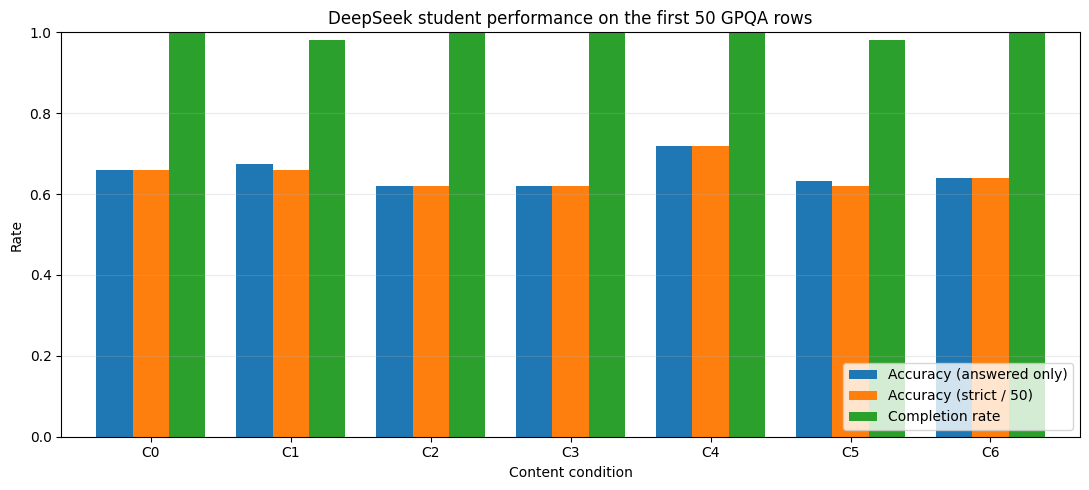

In [5]:
plot = summary[['accuracy_answered_only', 'accuracy_strict_50', 'completion_rate']].copy()
plot.index = [f'C{i}' for i in plot.index]
ax = plot.plot(kind='bar', figsize=(11, 5), ylim=(0, 1), width=0.78)
ax.set_title('DeepSeek student performance on the first 50 GPQA rows')
ax.set_ylabel('Rate')
ax.set_xlabel('Content condition')
ax.legend(['Accuracy (answered only)', 'Accuracy (strict / 50)', 'Completion rate'], loc='lower right')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Fully paired subset

This comparison uses only question IDs with an extracted answer in every condition. It is paired but may be very small when a condition has low completion.

In [6]:
answered_counts = analysis_rows.groupby('id')['prediction'].apply(lambda values: values.notna().sum())
paired_ids = set(answered_counts[answered_counts == len(CONDITION_LABELS)].index)
paired = analysis_rows[analysis_rows['id'].isin(paired_ids)]
paired_summary = paired.groupby('condition_id').agg(
    paired_rows=('id', 'size'), correct=('is_correct', 'sum')
)
paired_summary['paired_accuracy'] = paired_summary['correct'] / paired_summary['paired_rows']
print('Fully paired question count:', len(paired_ids))
display(paired_summary.style.format({'paired_accuracy': '{:.1%}'}))

Fully paired question count: 48


,paired_rows,correct,paired_accuracy
condition_id,,,
0,48,32,66.7%
1,48,33,68.8%
2,48,30,62.5%
3,48,30,62.5%
4,48,35,72.9%
5,48,30,62.5%
6,48,31,64.6%


## Unresolved rows

These rows remain excluded from answered-only accuracy. Missing rows were not run; rate-limited/provider-unavailable rows produced no model answer; `no_final_answer` means a model response existed but contained no extractable explicit choice.

In [7]:
unresolved = analysis_rows[analysis_rows['status'].isin(['missing_not_run', 'rate_limited', 'provider_unavailable', 'no_final_answer'])]
display(unresolved[['condition_id', 'position', 'id', 'status', 'source_file']].reset_index(drop=True))
print('Unresolved total:', len(unresolved))

,condition_id,position,id,status,source_file
0,1,20,rec2fEZkqcDWMh1JV,no_final_answer,teacher-deepseek-v4-flash__student-deepseek-de...
1,5,11,rec1BjNQici8oD53a,no_final_answer,teacher-deepseek-v4-flash__student-deepseek-de...


Unresolved total: 2
